# UIT-VSFC — Modelling results

Every number here is read live from `results/registry.csv` and `results/runs/*/metrics.json`.
Nothing is typed by hand, so this notebook cannot drift from what was actually run.

**Reporting rules** ([EVALUATION_PROTOCOL](../docs/EVALUATION_PROTOCOL.md)):
macro-F1 is the headline, weighted F1 sits beside it, every transformer number is a mean ± std
over 5 fixed seeds, and per-class F1 carries its bootstrap interval. The test split was
evaluated only at gates and every evaluation is logged.


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from vifeedback import paths
from vifeedback.constants import SEEDS
from vifeedback.evaluation import metrics as M
from vifeedback.evaluation.report import load_registry, test_evaluation_count

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3})

reg = load_registry()
print(f'{len(reg)} runs in the registry | {test_evaluation_count()} test-set evaluations logged')


def seeds_of(tag, split='tes'):
    out = []
    for s in SEEDS:
        p = paths.RUNS / f'{tag}-s{s}-{split}' / 'metrics.json'
        if p.exists():
            out.append(json.loads(p.read_text(encoding='utf-8')))
    return out


def agg(ms, key):
    v = np.array([m[key] for m in ms])
    return v.mean(), (v.std(ddof=1) if len(v) > 1 else 0.0), v


71 runs in the registry | 13 test-set evaluations logged


---

## 1. Headline — the test split

The test set was untouched until Gate G4. These are the only numbers the project claims.


In [2]:
CHAMP = 'p4-sent-phobert-base-seg_vncorenlp-base'
ms = seeds_of(CHAMP)

rows = []
for k in ('macro_f1', 'weighted_f1', 'accuracy', 'balanced_accuracy', 'g_mean', 'mcc', 'qwk'):
    m, s, _ = agg(ms, k)
    rows.append({'metric': k, 'mean': round(m, 4), 'std': round(s, 4)})
hdr = pd.DataFrame(rows).set_index('metric')
print(f'PhoBERT-base + VnCoreNLP segmentation | sentiment | TEST | {len(ms)} seeds')
hdr


PhoBERT-base + VnCoreNLP segmentation | sentiment | TEST | 5 seeds


,mean,std
metric,,
macro_f1,0.8373,0.0031
weighted_f1,0.9391,0.0020
accuracy,0.9421,0.0023
balanced_accuracy,0.8115,0.0038
g_mean,0.7764,0.0065
mcc,0.8933,0.0041
qwk,0.9350,0.0034


In [3]:
per = []
for n in ms[0]['labels']:
    v = np.array([m['per_class'][n]['f1'] for m in ms])
    per.append({
        'class': n,
        'support': ms[0]['per_class'][n]['support'],
        'F1 mean': round(v.mean(), 4),
        'F1 std': round(v.std(ddof=1), 4),
        'precision': round(np.mean([m['per_class'][n]['precision'] for m in ms]), 4),
        'recall': round(np.mean([m['per_class'][n]['recall'] for m in ms]), 4),
        'avg precision': round(np.mean([m['per_class'][n].get('average_precision', np.nan) for m in ms]), 4),
    })
pd.DataFrame(per)


,class,support,F1 mean,F1 std,precision,recall,avg precision
0,negative,1409,0.9577,0.0034,0.9448,0.9710,0.9775
1,neutral,167,0.5955,0.0070,0.7364,0.5006,0.6635
2,positive,1590,0.9587,0.0015,0.9545,0.9629,0.9877


**The whole project in one row.** `neutral` holds 167 of 3,166 test examples (5.3%) and scores
F1 ≈ 0.60 against ≈ 0.96 for both majority classes. Weighted F1 (0.939) barely notices; macro-F1
(0.837) is dragged down by a full tenth. Which number you report decides what the model looks like.


---

## 2. The ladder, dev split — what each step actually bought


In [4]:
dev = reg[reg.split == 'validation'].copy()


def dev_agg(model, prep, recipe='base', phase=None):
    q = dev[(dev.model == model) & (dev.preprocessing == prep) & (dev.recipe == recipe)]
    if phase:
        q = q[q.phase == phase]
    return (q.macro_f1.mean(), q.macro_f1.std(ddof=1) if len(q) > 1 else 0.0, len(q))


ladder = [
    ('B0 majority class', 'b0', 'raw', 'base'),
    ('B1 TF-IDF word + LR', 'b1', 'raw', 'base'),
    ('B2 TF-IDF char + LR', 'b2', 'raw', 'base'),
    ('B3 TF-IDF word+char + LR', 'b3', 'raw', 'base'),
    ('B4 TF-IDF + LinearSVC', 'b4', 'raw', 'base'),
    ('PhoBERT, raw text', 'phobert-base', 'raw', 'base'),
    ('PhoBERT + underthesea', 'phobert-base', 'seg_underthesea', 'base'),
    ('PhoBERT + pyvi', 'phobert-base', 'seg_pyvi', 'base'),
    ('PhoBERT + VnCoreNLP', 'phobert-base', 'seg_vncorenlp', 'base'),
]
out = []
for label, model, prep, recipe in ladder:
    m, s, n = dev_agg(model, prep, recipe)
    if n:
        out.append({'model': label, 'macro-F1': round(m, 4), 'std': round(s, 4), 'runs': n})
lad = pd.DataFrame(out)
lad


,model,macro-F1,std,runs
0,B0 majority class,0.2176,0.0100,2
1,B1 TF-IDF word + LR,0.7426,0.0085,2
2,B2 TF-IDF char + LR,0.7436,0.0128,2
3,B3 TF-IDF word+char + LR,0.7538,0.0013,2
4,B4 TF-IDF + LinearSVC,0.7660,0.0032,2
5,"PhoBERT, raw text",0.8204,0.0251,10
6,PhoBERT + underthesea,0.8618,0.0063,5
7,PhoBERT + pyvi,0.8454,0.0282,11
8,PhoBERT + VnCoreNLP,0.8671,0.0069,10


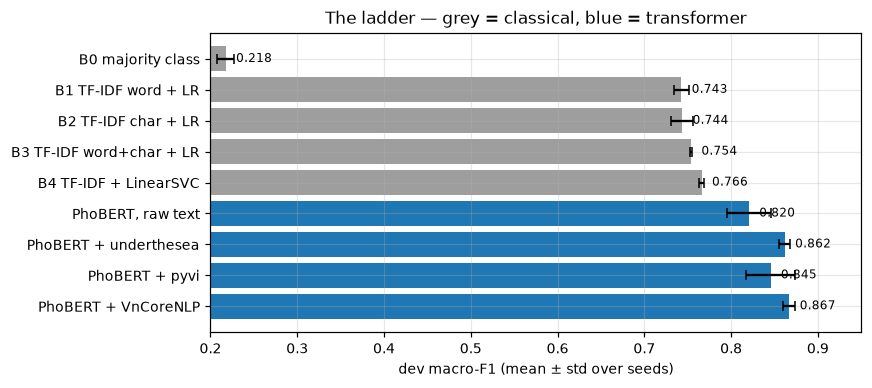

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(lad))[::-1]
ax.barh(y, lad['macro-F1'], xerr=lad['std'], capsize=3,
        color=['#9e9e9e'] * 5 + ['#1f77b4'] * (len(lad) - 5))
ax.set_yticks(y, lad['model'])
ax.set_xlim(0.2, 0.95)
ax.set_xlabel('dev macro-F1 (mean ± std over seeds)')
ax.set_title('The ladder — grey = classical, blue = transformer')
for yi, v in zip(y, lad['macro-F1']):
    ax.text(v + 0.012, yi, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()


---

## 3. The metric that hides the class, shown three ways

The same four models, measured by accuracy, weighted F1 and macro-F1.


In [6]:
cmp_ = []
for label, tag, split in [
    ('TF-IDF B3 (test)', 'g4-sent-b3-raw-devpriors', 'test'),
    ('PhoBERT raw (dev)', 'p2-sent-phobert-base-raw-base', 'val'),
    ('PhoBERT +seg (dev)', 'p3-sent-phobert-base-seg_vncorenlp-base', 'val'),
    ('PhoBERT +seg (TEST)', CHAMP, 'tes'),
]:
    mm = seeds_of(tag, split) or (
        [json.loads((paths.RUNS / f'{tag}-s42-{split}' / 'metrics.json').read_text(encoding='utf-8'))]
        if (paths.RUNS / f'{tag}-s42-{split}' / 'metrics.json').exists() else []
    )
    if not mm:
        continue
    cmp_.append({
        'model': label,
        'accuracy': round(np.mean([m['accuracy'] for m in mm]), 4),
        'weighted F1': round(np.mean([m['weighted_f1'] for m in mm]), 4),
        'macro F1': round(np.mean([m['macro_f1'] for m in mm]), 4),
        'neutral F1': round(np.mean([m['per_class']['neutral']['f1'] for m in mm]), 4),
    })
c = pd.DataFrame(cmp_)
c


,model,accuracy,weighted F1,macro F1,neutral F1
0,TF-IDF B3 (test),0.8834,0.8817,0.7450,0.4207
1,PhoBERT raw (dev),0.9449,0.9427,0.8436,0.6139
2,PhoBERT +seg (dev),0.9545,0.9529,0.8670,0.6680
3,PhoBERT +seg (TEST),0.9421,0.9391,0.8373,0.5955


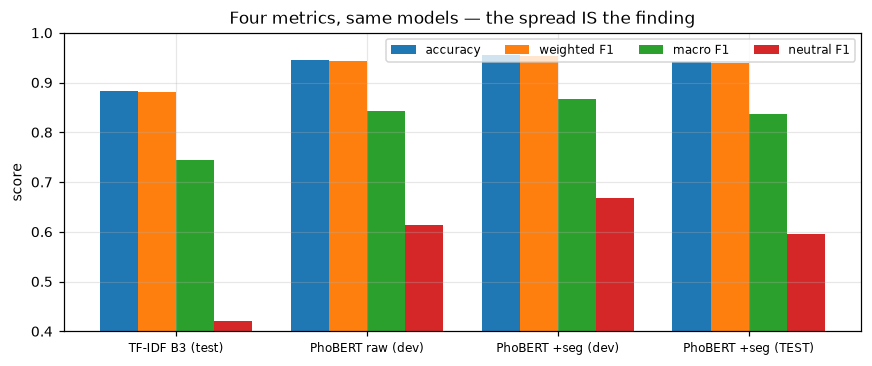

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.4))
x = np.arange(len(c))
w = 0.2
for i, col in enumerate(['accuracy', 'weighted F1', 'macro F1', 'neutral F1']):
    ax.bar(x + (i - 1.5) * w, c[col], w, label=col)
ax.set_xticks(x, c['model'], fontsize=8)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('score')
ax.set_title('Four metrics, same models — the spread IS the finding')
ax.legend(fontsize=8, ncol=4)
plt.tight_layout(); plt.show()


Accuracy and weighted F1 move within a few points across every model. Macro-F1 and neutral F1
move by tens of points. A paper reporting only the first pair would conclude these models are
nearly equivalent.


---

## 4. Confusion — where the errors actually are


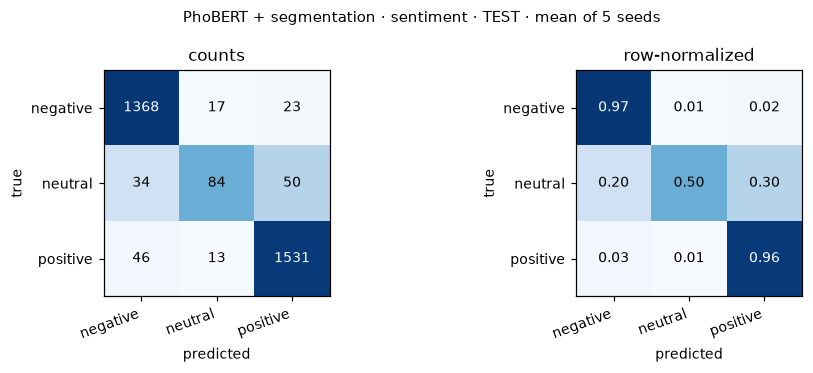

true neutral (n=167):  -> negative 20.2%   -> positive 29.7%   correct 50.1%
errors involving the middle class: 62.0% of all errors


In [8]:
cm = np.mean([np.array(m['confusion']) for m in ms], axis=0)
names = ms[0]['labels']
cmn = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, mat, title, fmt in ((axes[0], cm, 'counts', '{:.0f}'),
                            (axes[1], cmn, 'row-normalized', '{:.2f}')):
    im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(3), names, rotation=20, ha='right')
    ax.set_yticks(range(3), names)
    ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title(title)
    ax.grid(False)
    for r in range(3):
        for cc in range(3):
            ax.text(cc, r, fmt.format(mat[r, cc]), ha='center', va='center',
                    fontsize=9, color='white' if cmn[r, cc] > 0.55 else 'black')
fig.suptitle('PhoBERT + segmentation · sentiment · TEST · mean of 5 seeds', fontsize=10)
plt.tight_layout(); plt.show()

tot = cm[1].sum()
print(f'true neutral (n={tot:.0f}):  -> negative {cm[1,0]/tot:.1%}   -> positive {cm[1,2]/tot:.1%}'
      f'   correct {cm[1,1]/tot:.1%}')
adj = cm[0,1] + cm[1,0] + cm[1,2] + cm[2,1]
non = cm[0,2] + cm[2,0]
print(f'errors involving the middle class: {adj/(adj+non):.1%} of all errors')


**The ordinal signature.** True neutrals split almost evenly between the two poles — the shape
of a middle class the model cannot place, not of a class it confuses with one specific
neighbour. Nothing in a 3-way softmax knows that `negative < neutral < positive`, which is the
argument for the ordinal head proposed in [PROPOSALS T1](../docs/PROPOSALS.md).


---

## 5. Seed variance — why every number here carries a ±


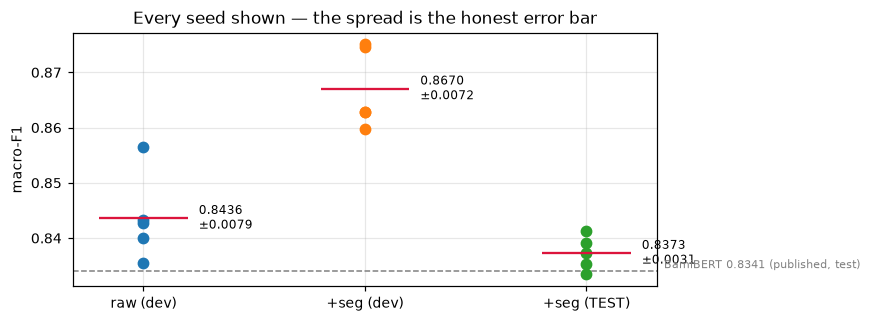

In [9]:
fig, ax = plt.subplots(figsize=(8, 3))
for i, (tag, split, label) in enumerate([
    ('p2-sent-phobert-base-raw-base', 'val', 'raw (dev)'),
    ('p3-sent-phobert-base-seg_vncorenlp-base', 'val', '+seg (dev)'),
    (CHAMP, 'tes', '+seg (TEST)'),
]):
    mm = seeds_of(tag, split)
    if not mm:
        continue
    v = [m['macro_f1'] for m in mm]
    ax.scatter([i] * len(v), v, s=45, zorder=3)
    ax.hlines(np.mean(v), i - 0.2, i + 0.2, colors='crimson', zorder=4)
    ax.text(i + 0.25, np.mean(v), f'{np.mean(v):.4f}\n±{np.std(v, ddof=1):.4f}', fontsize=8, va='center')
ax.axhline(0.8341, ls='--', color='grey', lw=1)
ax.text(2.35, 0.8341, 'BamiBERT 0.8341 (published, test)', fontsize=7, color='grey', va='bottom')
ax.set_xticks(range(3), ['raw (dev)', '+seg (dev)', '+seg (TEST)'])
ax.set_ylabel('macro-F1')
ax.set_title('Every seed shown — the spread is the honest error bar')
plt.tight_layout(); plt.show()


---

## 6. Against the published state of the art

Both figures are now on the **test** split, so the comparison is finally like for like.


In [10]:
mac = np.array([m['macro_f1'] for m in ms])
SOTA = 0.8341  # BamiBERT (2026), macro-F1, UIT-VSFC sentiment, test
BASE = 0.7450  # our honest TF-IDF baseline, test (B3 + dev-fitted priors)

print(f'  published SOTA (BamiBERT)  {SOTA:.4f}')
print(f'  ours                       {mac.mean():.4f} ± {mac.std(ddof=1):.4f}')
print(f'  difference                 {mac.mean()-SOTA:+.4f}  '
      f'= {(mac.mean()-SOTA)/mac.std(ddof=1):.1f} seed-std')
print(f'  seeds above SOTA           {(mac>SOTA).sum()}/{len(mac)}')
print()
print(f'  our honest TF-IDF baseline {BASE:.4f}')
print(f'  lift over baseline         {mac.mean()-BASE:+.4f}')


  published SOTA (BamiBERT)  0.8341
  ours                       0.8373 ± 0.0031
  difference                 +0.0032  = 1.0 seed-std
  seeds above SOTA           4/5

  our honest TF-IDF baseline 0.7450
  lift over baseline         +0.0923


### The claim this supports, and the one it does not

**+0.0032 over the published best is one seed-standard-deviation, with 4 of 5 seeds above it.**
That is *competitive*, not *better*. The project does not claim state of the art.

Worth noting how easily it could have. On **dev** the same model scored 0.8670 — a 3.3-point gap
that would have looked like a comfortable win. The dev→test drop is **−0.0298**, and the TF-IDF
baseline dropped **−0.026** in the same direction, so the gap is a property of the split rather
than of the model.

Reporting the dev number as the result would have been wrong, and nothing but running the locked
test split would have revealed it.


---

## 7. Success criteria, scored


In [11]:
neu = np.mean([m['per_class']['neutral']['f1'] for m in ms])
crit = pd.DataFrame([
    ['S1', 'Sentiment test macro-F1', 0.80, 0.84, round(mac.mean(), 4)],
    ['S3', 'Lift over honest baseline', 0.025, 0.05, round(mac.mean() - BASE, 4)],
    ['S4', 'Neutral-class F1', 0.55, 0.65, round(neu, 4)],
], columns=['id', 'criterion', 'minimum', 'target', 'measured'])
crit['verdict'] = np.where(crit.measured >= crit.target, 'target met',
                  np.where(crit.measured >= crit.minimum, 'minimum met', 'MISSED'))
crit


,id,criterion,minimum,target,measured,verdict
0,S1,Sentiment test macro-F1,0.800,0.84,0.8373,minimum met
1,S3,Lift over honest baseline,0.025,0.05,0.0923,target met
2,S4,Neutral-class F1,0.550,0.65,0.5955,minimum met


**S1 minimum met, target missed by 0.003. S3 target exceeded 1.8×. S4 minimum met, target missed.**

The two near-misses are both the neutral class, and both were predictable from the data card:
458 training examples spanning at least six unrelated phenomena.


---

## 8. What this notebook does not show

Stated because the omissions are the honest part of a results page:

* **Topic on test with segmentation** — running at the time of writing.
* **Error analysis** (Gate G5) and **inference optimization** (G6) — not started.
* **`phobert-large`, `xlm-roberta-base`, `CafeBERT`** — exceed the 4.29 GB laptop GPU; the
  Kaggle notebook exists and has not been run.
* **Anything about deployment** — the API, container and CI are Gate G7.

Current state and the plan for closing these: [`docs/STATUS.md`](../docs/STATUS.md).
